### ATTRITION ANALYSIS 

UNDERSTAND THE BUSINESS SCENARIO AND PROBLEM


The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

The goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

# PLAN STAGE 

IMPORTS AND DATASET UPLOAD

In [41]:
# import libraries and modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier , plot_importance 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score, precision_score, f1_score, classification_report

In [42]:
# upload the dataset

df0= pd.read_csv("HR_comma_sep.csv")

DATA EXPLORATION

In [43]:
# check whether the dataset is uploaded or not

df0.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [44]:
# check for datatypes

df0.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                   str
salary                       str
dtype: object

In [45]:
# basic information about the dataset

df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [5]:
# assess the number of rows and columns

df0.shape

(14999, 10)

In [9]:
# get the overall descriptive statistics of the dataset

df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [10]:
#check for missing values

df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [6]:
# check for duplicates

df0.duplicated().sum()

np.int64(3008)

In [ ]:
# view the duplicated rows

df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


DATA MANIPULATION

In [8]:
# drop duplicates

df1= df0.drop_duplicates(keep='first')


In [9]:
# check for duplicates after dropping

df1.duplicated().sum()


np.int64(0)

In [10]:
# recheck the shape of the dataset after dropping duplicates

df1.shape

(11991, 10)

In [11]:
# check for column names

df1.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [15]:
# modify column names appropriately

df1.rename(columns={ 'average_montly_hours':'average_monthly_hours', 'time_spend_company':'time_spent_company', 'Work_accident':'work_accident',  'Department':'department', 'time_spent_company':'tenure' }, inplace=True)

In [16]:
# check for column names after modification

df1.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')

###  Plan Stage Summary

- Defined the business objective: analyze employee data and build a model to predict attrition, helping improve retention and reduce hiring costs  

- Loaded and explored the dataset containing 14,999 rows and 10 features related to employee performance, satisfaction, and organizational factors  

- Reviewed dataset structure and column names to ensure clarity and consistency across all features  

- Identified data types, distinguishing between numerical variables (e.g., satisfaction level, working hours) and categorical variables (e.g., department, salary)  

- Performed missing value analysis → no null values found, confirming dataset completeness  

- Detected approximately 3,008 duplicate records (which is almost 20% of the original dataset) and removed them to prevent bias and redundancy  
  → final dataset size: 11,991 rows  

- Standardized column names to improve readability and maintain consistency for further analysis  

- Generated descriptive statistics to understand distributions, central tendencies, and variability of key numerical features  

- Established a clean, reliable dataset ready for deeper exploratory data analysis and modeling in the Analyze stage  

# ANALYZE STAGE

In [17]:
# check for unique values in the target variable

df1['left'].value_counts()

left
0    10000
1     1991
Name: count, dtype: int64

In [18]:
# check for percentage of employees who left the company

df1['left'].value_counts(normalize=True) * 100

left
0    83.39588
1    16.60412
Name: proportion, dtype: float64

DATA VISUALISATIONS

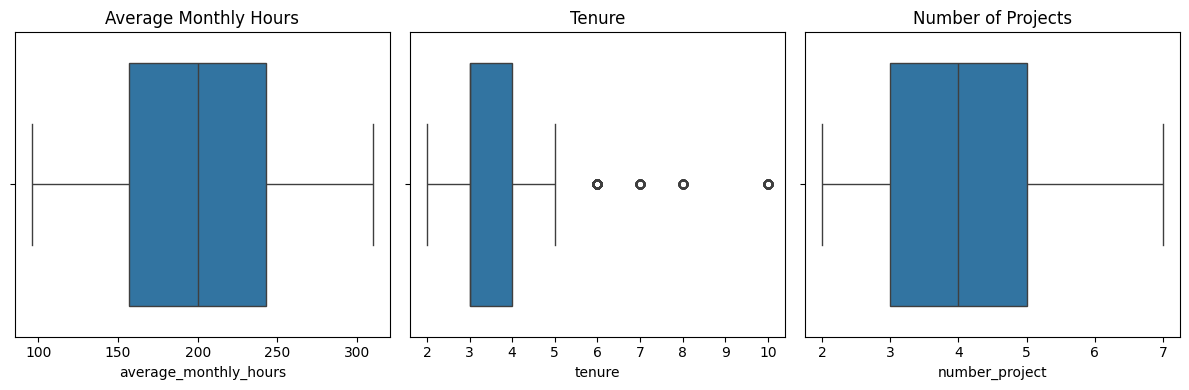

In [23]:
# check outliers in the dataset using boxplot

fig, axes = plt.subplots(1, 3, figsize=(12,4))

sns.boxplot(x=df1["average_monthly_hours"], ax=axes[0])
axes[0].set_title("Average Monthly Hours")

sns.boxplot(x=df1["tenure"], ax=axes[1])
axes[1].set_title("Tenure")

sns.boxplot(x=df1["number_project"], ax=axes[2])
axes[2].set_title("Number of Projects")

plt.tight_layout()
plt.show()

INSIGHTS

Average Monthly Hours: Wide IQR (~150–245 hrs) indicates high workload variability, with a symmetric distribution around ~200 hrs and no outliers.

Tenure: Most employees fall in the 3–4 year range, pointing to a relatively junior workforce. A few outliers at 6–10 years are worth monitoring for distinct attrition behaviour.

Number of Projects: Workload is concentrated around 3–5 projects (median: 4), with slight left skew suggesting very low assignments are uncommon.

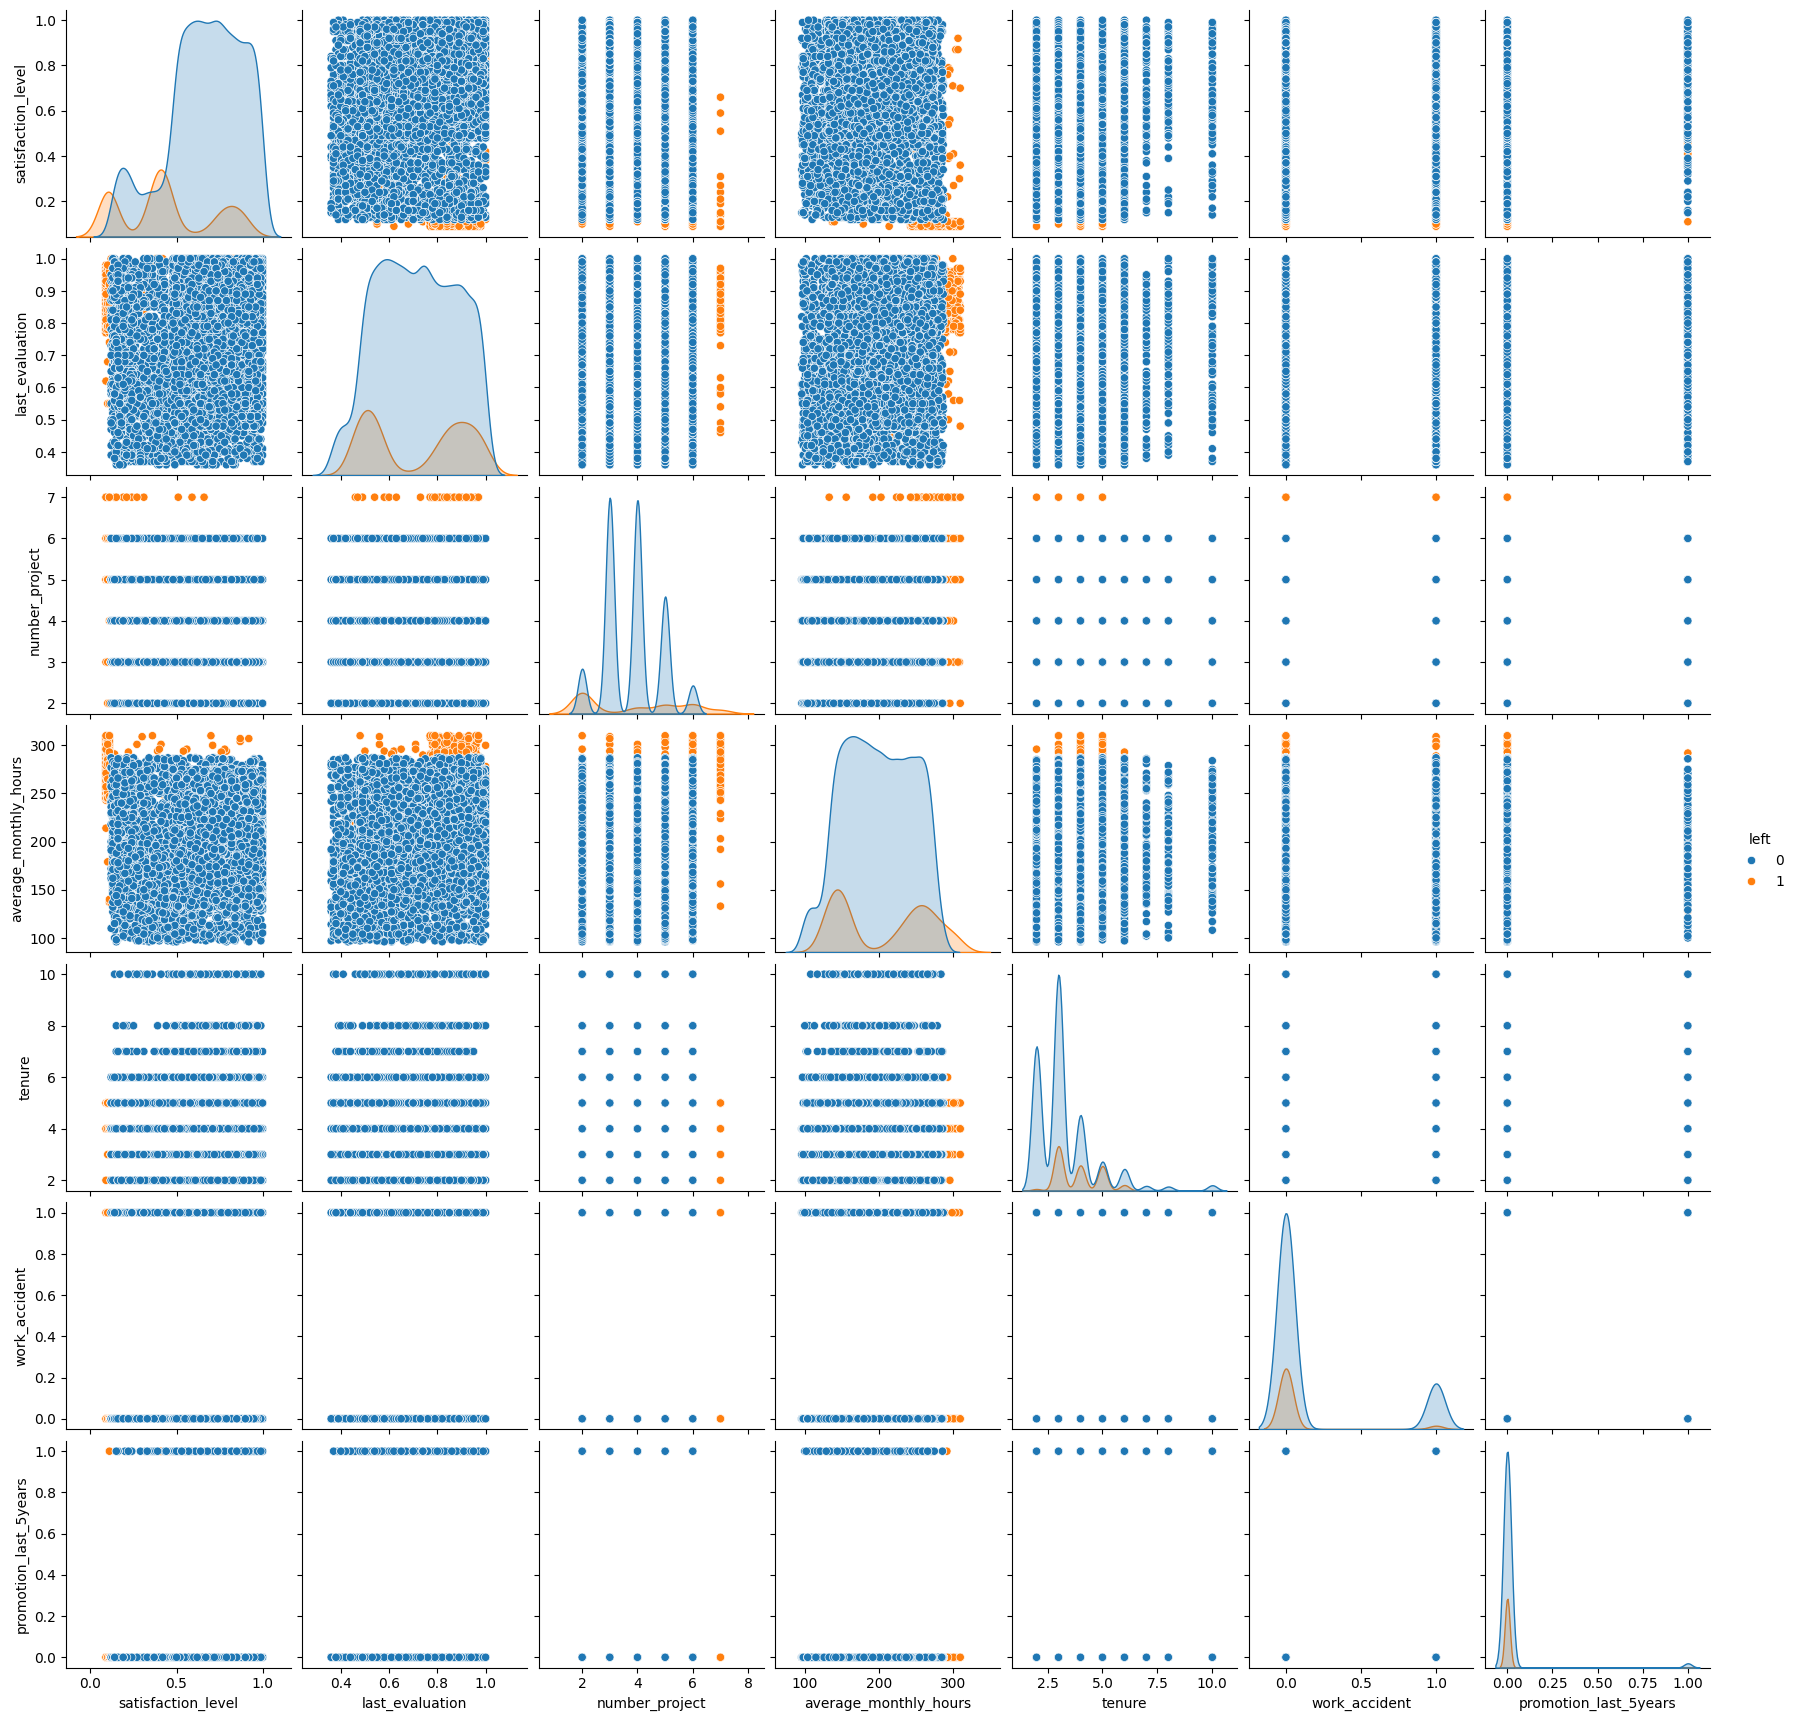

In [24]:
# check for correlation between the features using pairplot

sns.pairplot(df1,hue='left')

INSIGHTS

Satisfaction Level: Employees who left (orange) show a distinctly lower satisfaction distribution, heavily skewed toward 0.1–0.2, making it one of the strongest visual separators between the two groups.

Last Evaluation: Departed employees cluster at both extremes (low ~0.45 and high ~0.9+), suggesting both underperformers and high performers are leaving — a dual attrition risk pattern.

Number of Projects: Employees who left are concentrated at 2 and 6–7 projects, indicating burnout at high loads and disengagement at very low ones.

Average Monthly Hours: The left group shows a bimodal distribution — one cluster around 130–160 hrs (underutilised) and another at 250–310 hrs (overworked), mirroring the project count pattern.

Tenure: Attrition peaks around 3–5 years for employees who left, with very few departures beyond 6 years, suggesting a critical retention window in the early-to-mid career phase.

Work Accident & Promotion Last 5 Years: Both are binary and heavily imbalanced — promotions and accidents are rare across the board, with no strong visual separation between the two groups.

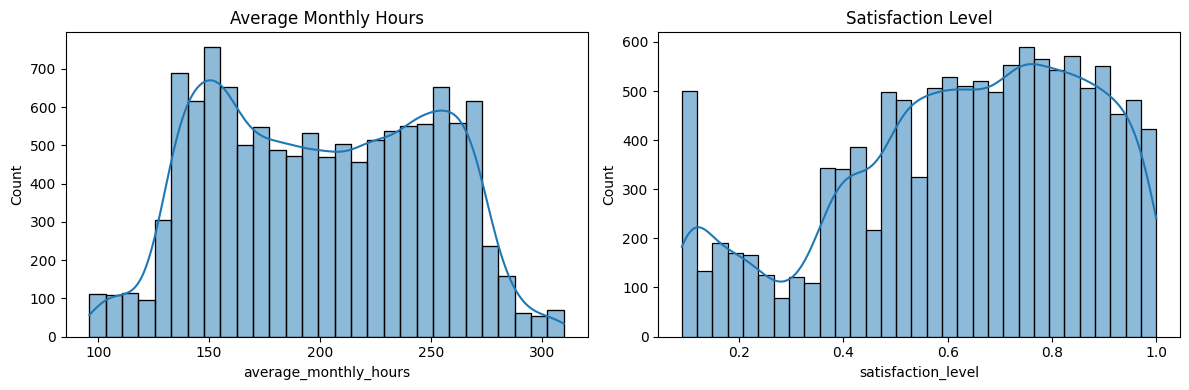

In [25]:
# check for distribution of average monthly hours and satisfaction level using a histogram

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(x=df1["average_monthly_hours"], kde=True,ax=axes[0])
axes[0].set_title("Average Monthly Hours")

sns.histplot(x=df1["satisfaction_level"],kde=True, ax=axes[1])
axes[1].set_title("Satisfaction Level")

plt.tight_layout()
plt.show()

INSIGHTS

Average Monthly Hours: The distribution is bimodal with peaks around 150 and 250 hrs, suggesting two distinct employee segments — a moderate-workload majority and a consistently overworked group, both relevant to attrition risk.

Satisfaction Level: Shows a dip between 0.2–0.4 before rising sharply toward 0.6–0.8, indicating a polarised workforce. The small spike near 0.1 likely represents highly dissatisfied employees and aligns closely with the attrition-prone group seen in the pair plot.

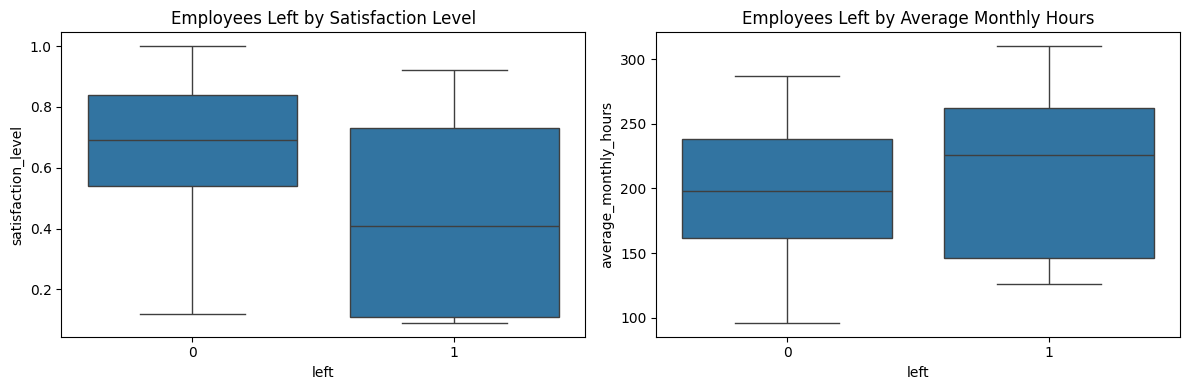

In [26]:
# assess the spread of the features with respect to the target variable (left) using boxplot

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x="left", y="satisfaction_level", data=df1, ax=axes[0])
axes[0].set_title("Employees Left by Satisfaction Level")
sns.boxplot(x="left", y="average_monthly_hours", data=df1, ax=axes[1])
axes[1].set_title("Employees Left by Average Monthly Hours")

plt.tight_layout()
plt.show()

INSIGHTS

Satisfaction Level by Attrition: Employees who left (1) have a notably lower median satisfaction (~0.4) and wider spread compared to those who stayed (0) at ~0.7, confirming satisfaction as a strong attrition predictor.

Average Monthly Hours by Attrition: Employees who left show a higher median (~230 hrs) and a wider IQR extending to 300 hrs, suggesting overwork is a consistent factor among those who departed.

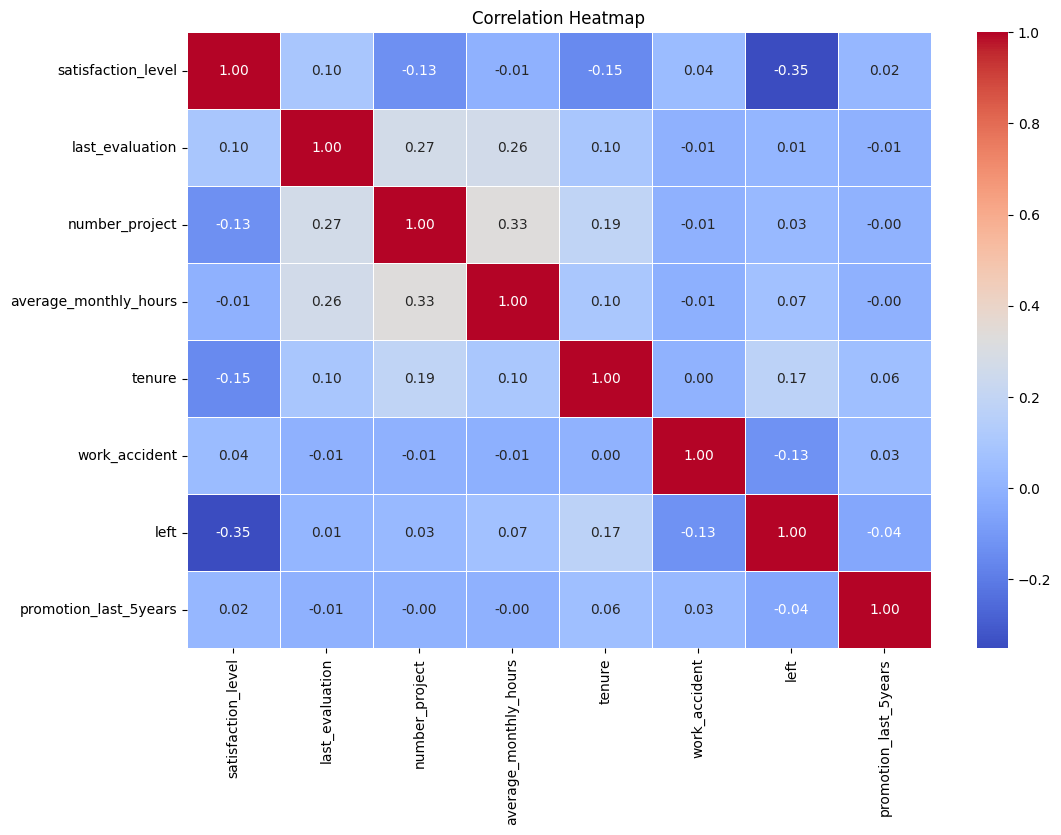

In [27]:
# check for correlation between the features using heatmap

plt.figure(figsize=(12,8))
corr = df1.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

INSIGHTS

Satisfaction level has the strongest link to attrition (-0.35), confirming it as the top predictor. Number of projects, monthly hours, and last evaluation cluster together (0.27–0.33), hinting at a burnout profile. Work accident and promotion are near-zero and unlikely to add model value. Low overall multicollinearity is a positive sign heading into the Construct stage.

In [19]:
# check mean and median satisfaction scores of employees who left and those who stayed

df1.groupby('left')['satisfaction_level'].agg(['mean', 'median'])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


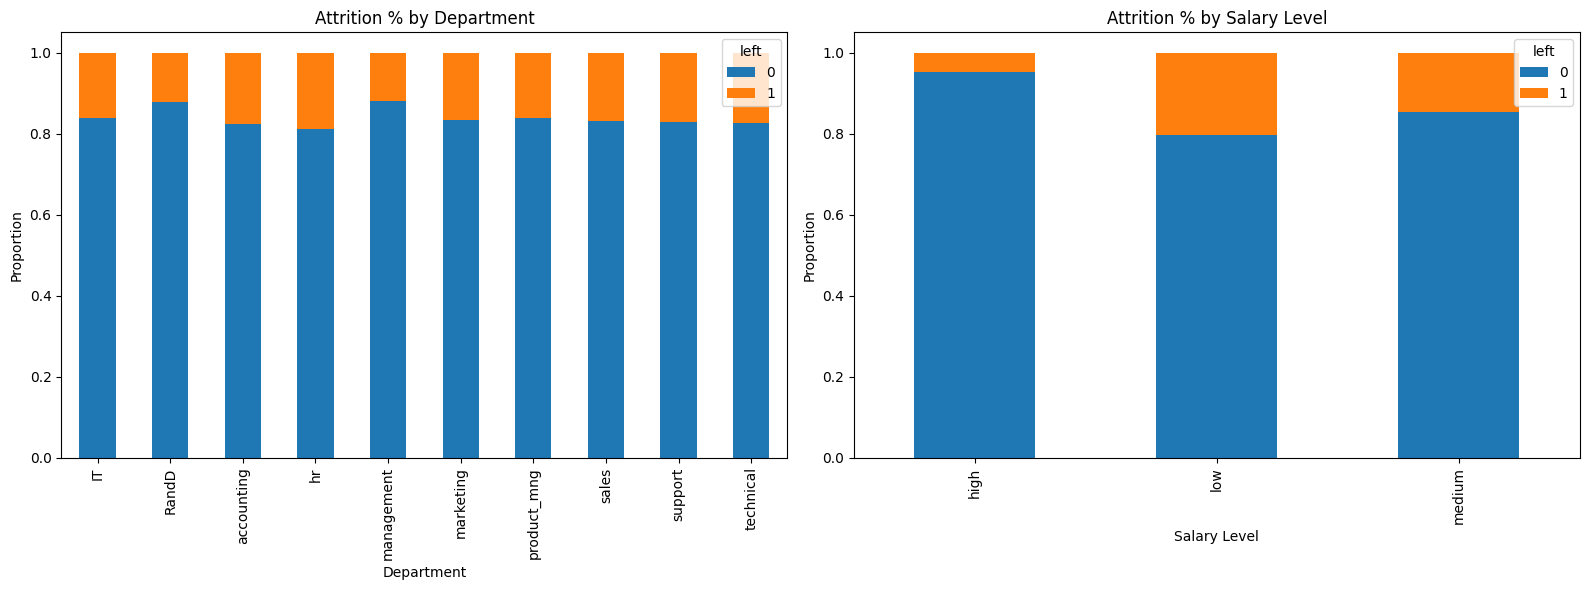

In [29]:
# visualize the attrition percentage by department and salary level using bar charts

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Plot 1: Department vs Attrition
pd.crosstab(df1['department'], df1['left'], normalize='index') \
    .plot(kind='bar', stacked=True, ax=axes[0])

axes[0].set_title("Attrition % by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Proportion")



# Plot 2: Salary vs Attrition
pd.crosstab(df1['salary'], df1['left'], normalize='index') \
    .plot(kind='bar', stacked=True, ax=axes[1])

axes[1].set_title("Attrition % by Salary Level")
axes[1].set_xlabel("Salary Level")
axes[1].set_ylabel("Proportion")



plt.tight_layout()
plt.show()

INSIGHTS

Attrition by Department: Attrition rates are fairly uniform across departments (~15–20%), with HR and technical showing slightly higher proportions — no single department stands out as a major outlier.

Attrition by Salary: Low and medium salary bands drive the bulk of attrition, while high earners have a near-negligible leaving rate, suggesting compensation is a meaningful retention factor.

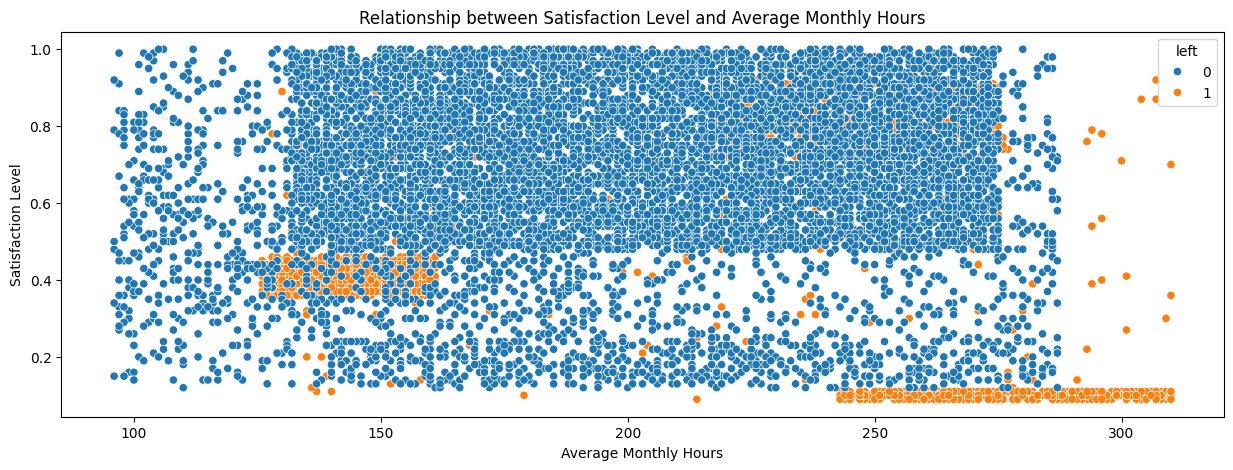

In [30]:
# make a scatterplot to check the relationship between satisfaction level and average monthly hours with respect to the target variable (left) 

plt.figure(figsize=(15,5))
sns.scatterplot(x="average_monthly_hours", y="satisfaction_level", hue="left", data=df1)
plt.title("Relationship between Satisfaction Level and Average Monthly Hours")
plt.xlabel("Average Monthly Hours")
plt.ylabel("Satisfaction Level")
plt.show()

INSIGHTS

Three distinct attrition clusters emerge: employees who left with low satisfaction (~0.1) across all hour ranges, those with moderate satisfaction (~0.4) and moderate hours (~150–220), and a high-hours group (270–310 hrs) with varied satisfaction — pointing to two separate attrition triggers: dissatisfaction and overwork.

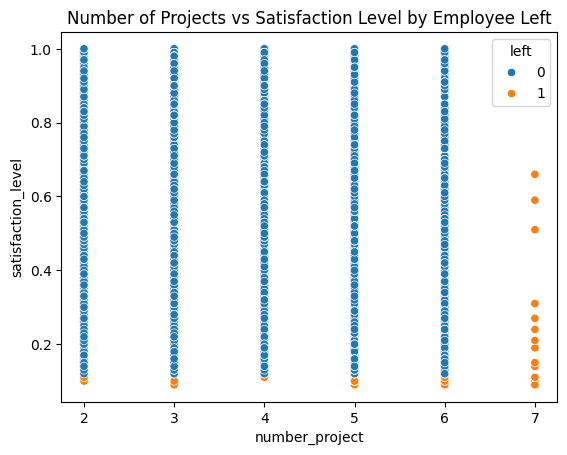

In [31]:
# number of projects with respect to the target variable (left)

sns.scatterplot(x="number_project", y="satisfaction_level", data=df1, hue="left")
plt.title("Number of Projects vs Satisfaction Level by Employee Left")
plt.show()

INSIGHTS

Employees who left cluster at 2 projects (low satisfaction ~0.1, disengagement) and 7 projects (100% attrition rate, wider satisfaction spread, overload). The 3–6 project range is dominated by retained employees, suggesting that balanced workloads are a natural retention zone.

### ANALYZE STAGE SUMMARY

Major Factors:
- satisfaction_level — strongest predictor, consistent across all plots
- average_monthly_hours — overworked cluster (270–310 hrs) clearly linked to attrition
- number_project — extremes (2 and 6–7 projects) drive leaving behaviour
- last_evaluation — high performers leaving suggests burnout, not just underperformance
- tenure — attrition peaks in the 3–5 year window, flags a critical retention zone

Secondary Factors:
- salary_level — low and medium earners leave at higher rates, though the pattern is less pronounced compared to the workload and satisfaction signals
Irrelevant 

Low Signal:
- work_accident — near-zero correlation, no visual separation
- promotion_last_5years — negligible impact on attrition
- department — uniform attrition rates across departments, low model value


# CONSTRUCT STAGE

### FEATURE ENGINEERING

In [20]:
# FEATURE SELECTION
# dropping of irrelevant or low model features based on the insights gathered from the correlation heatmap and pairplot

df_model = df1.drop(columns=['department', 'work_accident', 'promotion_last_5years'])
df_model.head(10)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,left,salary
0,0.38,0.53,2,157,3,1,low
1,0.80,0.86,5,262,6,1,medium
2,0.11,0.88,7,272,4,1,medium
3,0.72,0.87,5,223,5,1,low
4,0.37,0.52,2,159,3,1,low
5,0.41,0.50,2,153,3,1,low
6,0.10,0.77,6,247,4,1,low
7,0.92,0.85,5,259,5,1,low
8,0.89,1.00,5,224,5,1,low
9,0.42,0.53,2,142,3,1,low


In [21]:
# FEATURE CONSTRUCTION
# creation of new feature (overwork_flag) based on the existing features to capture more information and improve model performance

# create overwork flag
df_model['overwork_flag'] = (
    (df_model['average_monthly_hours'] >= 270) &
    (df_model['number_project'] >= 6)
).astype(int)

df_model['overwork_flag'].value_counts()

overwork_flag
0    11658
1      333
Name: count, dtype: int64

In [22]:
# FEATURE TRANSFORMATION
# encoding the 'salary' column to categorical ordinal values

salary_map = {'low': 0, 'medium': 1, 'high': 2}
df_model['salary'] = df1['salary'].map(salary_map).values

df_model['salary'].value_counts()

salary
0    5740
1    5261
2     990
Name: count, dtype: int64

In [46]:
# introducing the features and target variable into x and y respectively

x = df_model.drop(['left'], axis=1)
print(x.shape)
y = df_model['left']
print(y.shape)


(11991, 7)
(11991,)


In [26]:
# splitting the dataset for training , validation and testing of the model

# first split off test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)

# split remaining 80% into train (80%) and val (20%) → 64/16 of total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)


### DECISION TREE

In [27]:
%%time

# decision tree - hyperparameter tuning using gridsearchcv

dt_params = {
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'max_features':      ['sqrt', 'log2', None],
    'class_weight':      ['balanced', None]
}

# instantiate the grid search with the decision tree classifier and the defined hyperparameters
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, scoring='recall', cv=5, n_jobs=-1)

# fit the grid search to the training data
dt_grid.fit(X_train, y_train)

# get the best hyperparameters and the best recall score from the grid search
print(dt_grid.best_params_)
print(dt_grid.best_score_)

{'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2}
0.9426895167515825
CPU times: total: 3.14 s
Wall time: 12.9 s


### RANDOM FOREST

In [28]:
%%time

# random forest - hyperparameter tuning using gridsearchcv

rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 5],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced', None]
}

# instantiate the grid search with the random forest classifier and the defined hyperparameters
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, scoring='recall', cv=5, n_jobs=-1)

# fit the grid search to the training data
rf_grid.fit(X_train, y_train)

# get the best hyperparameters and the best recall score from the grid search
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
0.9120951057588391
CPU times: total: 13 s
Wall time: 5min 23s


### XGBOOST

In [29]:
%%time

# xgboost - hyperparameter tuning using gridsearchcv

xgb_params = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 3, 5]
}

# instantiate the grid search with the xgboost classifier and the defined hyperparameters
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_params, scoring='recall', cv=5, n_jobs=-1)

# fit the grid search to the training data
xgb_grid.fit(X_train, y_train)

# get the best hyperparameters and the best recall score from the grid search
print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 5, 'subsample': 0.6}
0.937211672070403
CPU times: total: 35 s
Wall time: 3min 37s


# EXECUTE

TESTING THE 3 MODELS WITH ITS BEST PARAMETERS ON THE VALIDATION SET TO PICK THE CHAMPION MODEL

In [30]:
# refit all three models using best parameters from gridsearchcv

dt_model  = dt_grid.best_estimator_
rf_model  = rf_grid.best_estimator_
xgb_model = xgb_grid.best_estimator_

              precision    recall  f1-score   support

           0       0.98      0.62      0.76      1600
           1       0.33      0.94      0.49       319

    accuracy                           0.67      1919
   macro avg       0.66      0.78      0.62      1919
weighted avg       0.87      0.67      0.72      1919



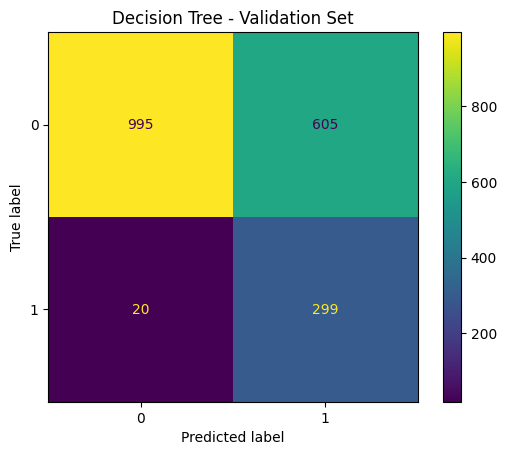

In [35]:
# decision tree - validation set evaluation

dt_val_preds = dt_model.predict(X_val)

print(classification_report(y_val, dt_val_preds))
ConfusionMatrixDisplay.from_predictions(y_val, dt_val_preds)
plt.title('Decision Tree - Validation Set')
plt.show()

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1600
           1       0.93      0.92      0.92       319

    accuracy                           0.97      1919
   macro avg       0.96      0.95      0.95      1919
weighted avg       0.97      0.97      0.97      1919



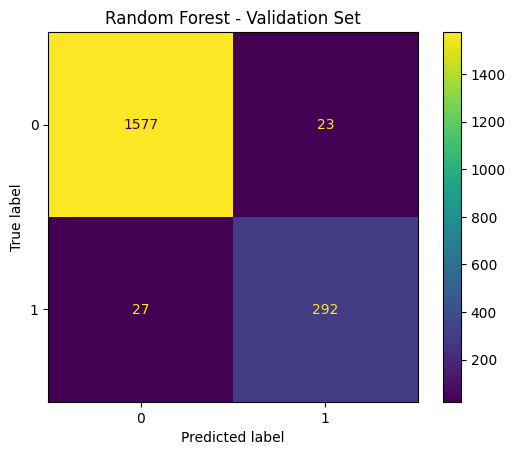

In [36]:
# random forest - validation set evaluation

rf_val_preds = rf_model.predict(X_val)

print(classification_report(y_val, rf_val_preds))
ConfusionMatrixDisplay.from_predictions(y_val, rf_val_preds)
plt.title('Random Forest - Validation Set')
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1600
           1       0.70      0.94      0.80       319

    accuracy                           0.92      1919
   macro avg       0.84      0.93      0.88      1919
weighted avg       0.94      0.92      0.93      1919



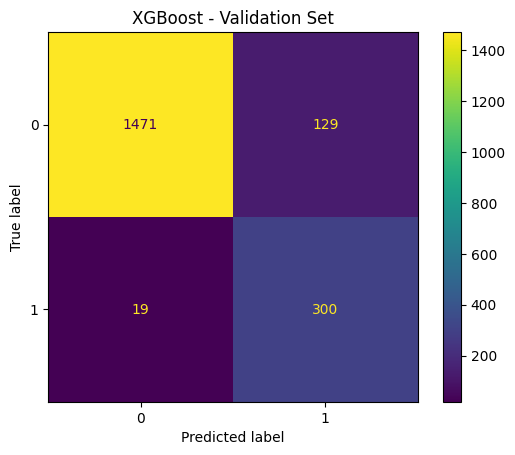

In [37]:
# xgboost - validation set evaluation

xgb_val_preds = xgb_model.predict(X_val)

print(classification_report(y_val, xgb_val_preds))
ConfusionMatrixDisplay.from_predictions(y_val, xgb_val_preds)
plt.title('XGBoost - Validation Set')
plt.show()

In [38]:
# model comparison on validation set

results = {
    'Model':     ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Precision': [0.33, 0.93, 0.70],
    'Recall':    [0.94, 0.92, 0.94],
    'F1':        [0.49, 0.92, 0.80],
    'Accuracy':  [0.67, 0.97, 0.92]
}

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Precision,Recall,F1,Accuracy
Model,,,,
Decision Tree,0.33,0.94,0.49,0.67
Random Forest,0.93,0.92,0.92,0.97
XGBoost,0.70,0.94,0.80,0.92


CROWNING THE CHAMPION MODEL AND USING IT ON THE TEST SET 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2001
           1       0.93      0.92      0.93       398

    accuracy                           0.98      2399
   macro avg       0.96      0.96      0.96      2399
weighted avg       0.98      0.98      0.98      2399



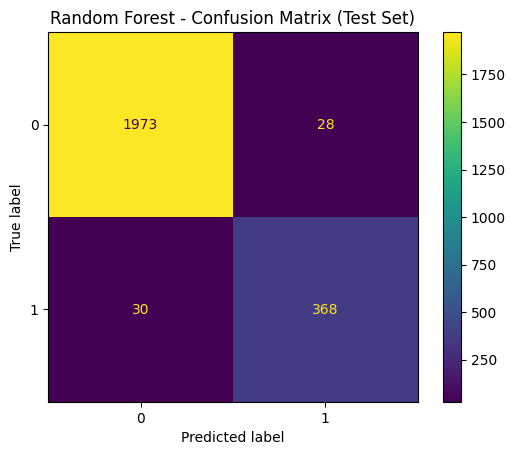

In [39]:
# CHAMPION MODEL - RANDOM FOREST
# final evaluation on the locked test set to get the true generalization performance of the model

rf_test_preds = rf_model.predict(X_test)

print(classification_report(y_test, rf_test_preds))

# confusion matrix for the champion model on the test set
ConfusionMatrixDisplay.from_predictions(y_test, rf_test_preds)
plt.title('Random Forest - Confusion Matrix (Test Set)')
plt.show()

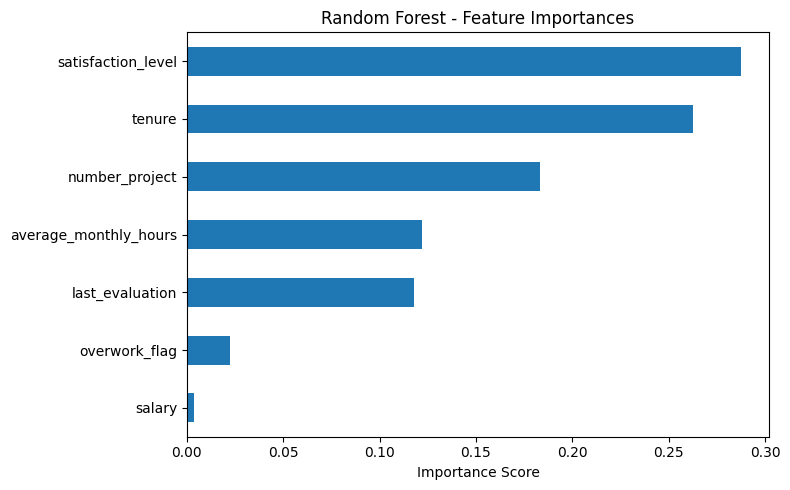

In [47]:
# feature importance - identifying the most influential features in the champion model

feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

# plot the feature importances
feat_imp.plot(kind='barh', figsize=(8, 5))
plt.title('Random Forest - Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Conclusion

The goal of this project was to build a model that predicts whether an employee at Salifort Motors is likely to leave — enabling the HR team to intervene before attrition occurs.

After evaluating three models, the **Random Forest classifier** was selected as the champion based on its performance on the held-out validation set, where it produced the best balance of precision and recall — outperforming both the Decision Tree (precision: 0.33) and XGBoost (precision: 0.70) on the attrition class.

On the final test set, the model achieved:
- **98% overall accuracy**
- **0.92 recall** — correctly identifying 9 out of every 10 employees who actually left
- **0.93 precision** — with only 28 false alarms out of 2,001 retained employees

The **Feature Importance** analysis confirms that `satisfaction_level` is the primary driver of attrition, followed closely by `tenure` and `number_project`. This suggests that attrition at Salifort Motors is fundamentally an engagement and workload problem — not a compensation one, given that `salary` ranked last among all predictors.

## RECOMMENDATIONS

The model makes one thing unambiguous — Salifort Motors does not have a compensation problem, it has a burnout and disengagement problem. Salary ranked last among all predictors while satisfaction, tenure, and workload dominate the top of the feature importance chart. The following recommendations are a direct response to what the data is saying.

---

**1. Enforce a Hard Ceiling on Workload**

Problem Identified: Employees carrying 6 or more projects alongside 270+ monthly hours left at an 87% rate. This is not a risk factor — it is a near-deterministic outcome. The company is systematically overloading a subset of its workforce and losing them as a direct consequence.

Recommended Steps:
- Cap individual project assignments at 5. Any request to assign a 6th project should require explicit managerial sign-off with a documented justification.
- Flag any employee consistently exceeding 270 monthly hours for an automatic workload review the following month.
- Audit current project distribution across teams to identify whether overloading is concentrated in specific departments or roles — the EDA showed this is not random.
- Explore where automation or additional hiring can absorb excess workload rather than stacking it onto existing employees.

---

**2. Build a Retention Strategy Around the 3-6 Year Tenure Window**

Problem Identified: Attrition peaks sharply in the mid-tenure range. These are fully trained, fully productive employees — the most expensive cohort to lose and replace. The data suggests Salifort is effective at onboarding but fails to sustain engagement past the initial phase, when employees begin benchmarking their growth and workload against their expectations.

Recommended Steps:
- Introduce structured career development conversations specifically at the 2-year and 4-year marks — before attrition risk peaks, not after.
- Create visible internal mobility pathways so mid-tenure employees see a future within the company rather than outside it.
- Assign a dedicated HR touchpoint for employees in the 3-6 year bracket whose satisfaction scores have dropped, prioritizing them for stay interviews before they reach the decision point.
- Review whether promotion and recognition cycles are actually reaching this cohort or whether they are being passed over in favor of newer or more senior employees.

---

**3. Replace Annual Satisfaction Surveys With Quarterly Pulse Checks**

Problem Identified: Satisfaction level is the single strongest predictor of attrition in the entire model. Yet measuring it once a year means HR is always working with stale data. By the time a drop in satisfaction appears on an annual review, the employee has in most cases already made their decision.

Recommended Steps:
- Implement lightweight quarterly pulse surveys — 5 to 8 questions maximum — focused on workload, recognition, and growth. The goal is lead time, not comprehensiveness.
- Use the champion model each quarter by feeding updated satisfaction scores to generate a ranked list of at-risk employees. HR can then prioritize outreach based on model output rather than gut feel.
- Track satisfaction trends at the team level, not just individually. A team-wide drop is a management problem, not an individual one, and should trigger a separate intervention at the managerial level.

---

**4. Stop Treating High Performers as Infinitely Resilient**

Problem Identified: Employees with high last_evaluation scores are leaving at rates comparable to low performers. The company appears to be rewarding strong performance with more work rather than with relief, recognition, or advancement — effectively penalizing its best people for being good at their jobs.

Recommended Steps:
- Decouple high performance from automatic workload increases. A strong evaluation score should trigger a conversation about growth and recognition — not an additional project assignment.
- Introduce performance-linked benefits that go beyond salary, such as flexible scheduling, project choice, or reduced mandatory hours — given that salary is the weakest predictor, non-monetary recognition is likely to have a stronger retention impact.
- Monitor the satisfaction-to-evaluation ratio as an internal metric. A high evaluation paired with a declining satisfaction score is the clearest early warning signal the data provides.

---

**5. Deploy the Model as a Living HR Tool**

Problem Identified: The model was built on historical data and evaluated at a single point in time. Attrition risk is not static — it evolves as employees change roles, accumulate projects, and shift in satisfaction. Treating this as a one-time analysis wastes its full potential.

Recommended Steps:
- Integrate the Random Forest model into a quarterly HR workflow where updated employee data is scored and an attrition risk ranking is produced for the HR team to act on.
- Define clear escalation thresholds — for example, any employee scoring above a defined risk probability triggers a mandatory check-in within 30 days.
- Retrain the model annually on fresh data to ensure it reflects any structural changes in the workforce, particularly if the company grows significantly or undergoes organizational restructuring.
- Use the model's output not just reactively but strategically — departments with consistently high predicted attrition should prompt a review of management practices, not just individual employee interventions.